In [99]:
# Task 4 - Logistic Regression
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [100]:
# Load the dataset

df = pd.read_csv('/content/data.csv')

# Display the first 5 rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
# Check dataset structure

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (569, 33)

Column names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non

In [103]:
# Check the target variable distribution

print("Diagnosis distribution:")
print(df['diagnosis'].value_counts())

print("\nDiagnosis percentages:")
print(df['diagnosis'].value_counts(normalize=True) * 100)

Diagnosis distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Diagnosis percentages:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [104]:
# Remove unnecessary columns

df_clean = df.drop(
    columns=['id', 'Unnamed: 32']
)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

df_clean.head()

Original shape: (569, 33)
Cleaned shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [105]:
# Check for missing values

print("Missing values:")
print(df_clean.isnull().sum().sum())

Missing values:
0


In [106]:
# Encode the target variable

df_clean['diagnosis'] = df_clean['diagnosis'].map({
    'M': 1,
    'B': 0
})

print("Encoded diagnosis values:")
print(df_clean['diagnosis'].value_counts())

Encoded diagnosis values:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [107]:
# Separate features (X) and target (y)

X = df_clean.drop('diagnosis', axis=1)
y = df_clean['diagnosis']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.unique())

Feature shape: (569, 30)
Target shape: (569,)

Target classes:
[1 0]


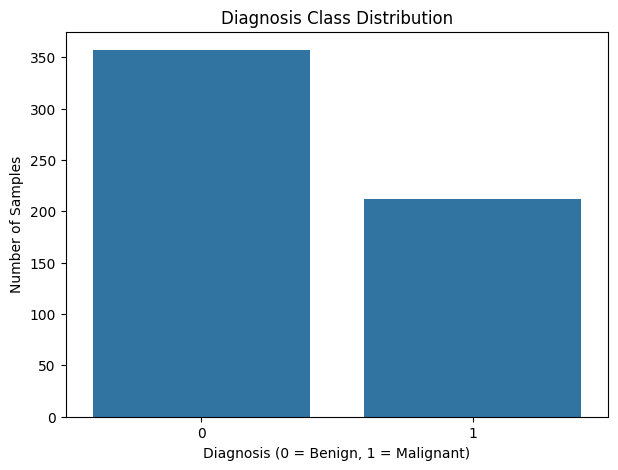

In [108]:
# Visualize class distribution

plt.figure(figsize=(7, 5))

sns.countplot(x=y)

plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Number of Samples")

plt.show()

In [109]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (455, 30)
Testing set: (114, 30)


In [110]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized successfully!")

Features standardized successfully!


In [111]:
scaler.fit_transform(X_train)

array([[ 0.51855873,  0.89182579,  0.4246317 , ..., -0.23574392,
         0.05456632,  0.02183673],
       [-0.51636409, -1.63971029, -0.54134872, ..., -0.32320788,
        -0.13757624, -0.90440164],
       [-0.36811839,  0.45551496, -0.38824993, ..., -0.89082504,
        -0.675893  , -0.14401559],
       ...,
       [-0.32616206,  1.33280304, -0.38905998, ..., -0.84289958,
        -0.96490082, -1.16888375],
       [ 0.00948859,  0.25952507,  0.00786279, ...,  0.27571059,
        -0.60284707, -0.30545988],
       [ 0.80945595,  0.36918608,  0.79320285, ...,  1.00657384,
        -0.46151907, -0.44817001]])

In [112]:
scaler.transform(X_test)

array([[-0.77089916, -2.00602473, -0.76451652, ..., -0.38805702,
         0.16254727,  0.06095804],
       [ 1.89472636,  0.96648861,  1.89081582, ...,  1.42292627,
         0.33722232, -0.31041892],
       [ 0.56051506, -0.78108791,  0.57044007, ...,  0.14391558,
         0.38009711,  0.30174696],
       ...,
       [ 0.10179251, -0.01812727,  0.08238707, ..., -0.29280517,
        -0.70288824, -0.52310661],
       [ 0.26682074, -0.63876192,  0.26586259, ...,  0.14541325,
         0.79614133,  0.73153038],
       [ 0.53254417,  0.05420233,  0.48133495, ...,  0.54678897,
        -0.41864428, -1.11598733]])

In [113]:
# Check the standardized features

print("First 5 rows of standardized training data:")
print(X_train_scaled[:5])

print("\nMean of first feature:", X_train_scaled[:, 0].mean())
print("Standard deviation of first feature:", X_train_scaled[:, 0].std())

First 5 rows of standardized training data:
[[ 5.18558727e-01  8.91825791e-01  4.24631702e-01  3.83925436e-01
  -9.74743706e-01 -6.89771505e-01 -6.88586446e-01 -3.98175254e-01
  -1.03915470e+00 -8.25056321e-01 -1.09317755e-01 -5.59755400e-02
  -2.10096206e-01 -1.59132582e-02 -1.00518399e+00 -9.11941990e-01
  -6.62815884e-01 -6.52561081e-01 -7.01889114e-01 -2.75393571e-01
   5.79797697e-01  1.31324246e+00  4.66908134e-01  4.45982711e-01
  -5.96154777e-01 -6.34722227e-01 -6.10227299e-01 -2.35743918e-01
   5.45663235e-02  2.18367276e-02]
 [-5.16364088e-01 -1.63971029e+00 -5.41348716e-01 -5.42961327e-01
   4.76219058e-01 -6.31833818e-01 -6.04281166e-01 -3.03074908e-01
   5.21543093e-01 -4.54522896e-01 -6.04377961e-01 -1.00104604e+00
  -5.85429002e-01 -4.93453793e-01  4.03212009e-01 -7.68173276e-01
  -4.79187222e-01  1.14508478e-01 -1.42950761e-01 -5.77397732e-01
  -5.82458953e-01 -1.69029101e+00 -6.11934288e-01 -5.87013537e-01
   2.73581959e-01 -8.14844486e-01 -7.12666415e-01 -3.23207881e-

In [114]:
# Create and train the Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [115]:
# Make predictions on the test set

y_pred = logistic_model.predict(X_test_scaled)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]


In [116]:
# Get predicted probabilities

y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("First 20 predicted probabilities:")
print(y_prob[:20])

First 20 predicted probabilities:
[3.64568116e-04 9.99999989e-01 4.25679471e-02 5.76187322e-01
 5.09155489e-01 6.16001620e-04 7.61534086e-01 1.01217174e-03
 5.68725516e-04 1.07675795e-02 9.30905953e-01 7.28319772e-05
 9.99999899e-01 4.39449272e-03 7.75262630e-03 1.70641370e-06
 6.14294329e-02 3.62811536e-04 2.21762013e-01 5.07279789e-05]


Confusion Matrix:
[[71  1]
 [ 3 39]]


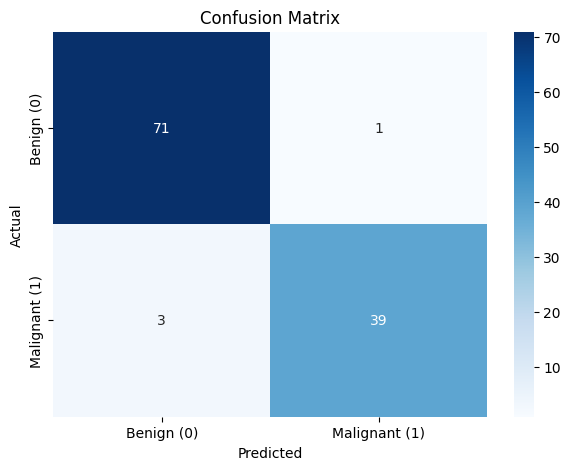

In [117]:
# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign (0)', 'Malignant (1)'],
    yticklabels=['Benign (0)', 'Malignant (1)']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [118]:
# Calculate classification metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Classification Metrics")
print("----------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")

Classification Metrics
----------------------
Accuracy  : 0.9649
Precision : 0.9750
Recall    : 0.9286


In [119]:
# Calculate ROC-AUC

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9960


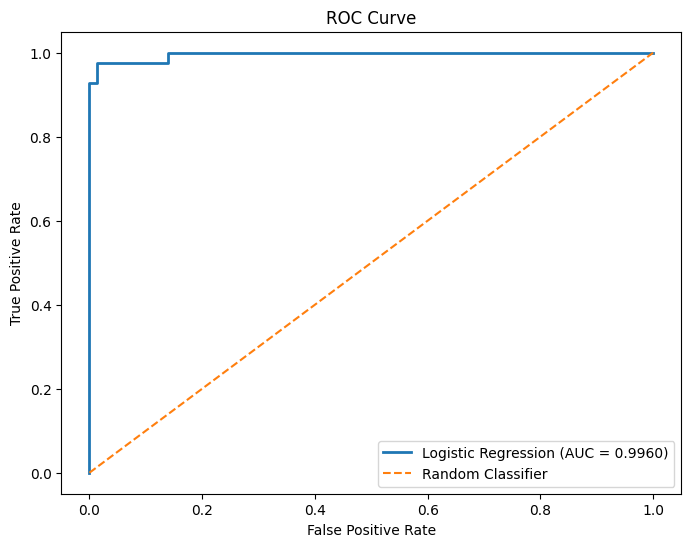

In [120]:
# Plot the ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Logistic Regression (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

In [121]:
# Threshold tuning

thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds_to_test:
    y_threshold_pred = (y_prob >= threshold).astype(int)

    threshold_precision = precision_score(
        y_test,
        y_threshold_pred,
        zero_division=0
    )

    threshold_recall = recall_score(
        y_test,
        y_threshold_pred,
        zero_division=0
    )

    threshold_results.append({
        'Threshold': threshold,
        'Precision': threshold_precision,
        'Recall': threshold_recall
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall
0,0.3,0.97619,0.976190
1,0.4,0.97561,0.952381
2,0.5,0.97500,0.928571
3,0.6,1.00000,0.904762
4,0.7,1.00000,0.904762


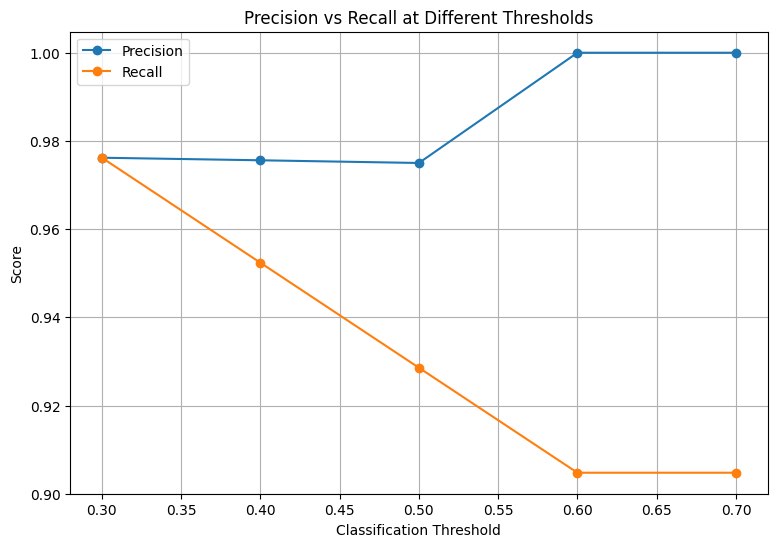

In [122]:
# Visualize precision-recall trade-off at different thresholds

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results_df['Threshold'],
    threshold_results_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_results_df['Threshold'],
    threshold_results_df['Recall'],
    marker='o',
    label='Recall'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Apply the selected classification threshold

chosen_threshold = 0.30

y_pred_tuned = (y_prob >= chosen_threshold).astype(int)

tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Threshold-Tuned Results")
print("-----------------------")
print(f"Threshold : {chosen_threshold}")
print(f"Accuracy  : {tuned_accuracy:.4f}")
print(f"Precision : {tuned_precision:.4f}")
print(f"Recall    : {tuned_recall:.4f}")

# Sigmoid Function

Logistic Regression uses the sigmoid function to convert a model's output into a probability between 0 and 1.

The sigmoid function is:

σ(z) = 1 / (1 + e^(-z))

where `z` is the linear combination of the input features.

The output of the sigmoid function represents the predicted probability of the positive class.

For this project:

- A probability closer to 0 indicates a higher likelihood of a benign diagnosis.
- A probability closer to 1 indicates a higher likelihood of a malignant diagnosis.

By default, Logistic Regression uses a threshold of 0.50:

- Probability ≥ 0.50 → predict malignant (1)
- Probability < 0.50 → predict benign (0)

For this project, threshold tuning showed that a threshold of 0.30 provided a better balance between precision and recall.

At threshold 0.30:

- Precision = 97.62%
- Recall = 97.62%

The lower threshold makes the classifier more sensitive to potential malignant cases and therefore helps reduce false negatives.

# Final Analysis and Conclusion

## 1. Model Performance

A Logistic Regression classifier was trained to classify breast cancer cases as benign or malignant.

The model achieved the following results at the default classification threshold of 0.50:

- Accuracy: 96.49%
- Precision: 97.50%
- Recall: 92.86%
- ROC-AUC: 0.9960

The high ROC-AUC indicates that the model has excellent ability to distinguish between benign and malignant cases.

## 2. Confusion Matrix

The confusion matrix was used to examine correct and incorrect classifications.

It provides four outcomes:

- True Positive: Malignant cases correctly identified.
- True Negative: Benign cases correctly identified.
- False Positive: Benign cases incorrectly classified as malignant.
- False Negative: Malignant cases incorrectly classified as benign.

For a medical classification problem, false negatives are particularly important because they represent malignant cases that the model failed to identify.

## 3. Threshold Tuning

The default threshold of 0.50 was compared with thresholds of 0.30, 0.40, 0.50, 0.60, and 0.70.

| Threshold | Precision | Recall |
|---:|---:|---:|
| 0.30 | 97.62% | 97.62% |
| 0.40 | 97.56% | 95.24% |
| 0.50 | 97.50% | 92.86% |
| 0.60 | 100.00% | 90.48% |
| 0.70 | 100.00% | 90.48% |

A threshold of 0.30 was selected for this project because it provided a strong balance between precision and recall while increasing recall compared with the default 0.50 threshold.

At threshold 0.30:

- Precision = 97.62%
- Recall = 97.62%

## 4. Sigmoid Function

Logistic Regression uses the sigmoid function to convert the model's output into a probability between 0 and 1.

The sigmoid function is:

σ(z) = 1 / (1 + e^(-z))

The resulting probability is then compared with a classification threshold to determine the predicted class.

## 5. Final Conclusion

The Logistic Regression model performed strongly on the test dataset.

The default model achieved 96.49% accuracy and an ROC-AUC of 0.9960.

Threshold tuning demonstrated that changing the classification threshold can alter the balance between precision and recall. A threshold of 0.30 provided a higher recall of 97.62% while maintaining precision of 97.62%.

This project demonstrated binary classification, feature standardization, Logistic Regression, classification metrics, ROC-AUC analysis, threshold tuning, and interpretation of the sigmoid function.